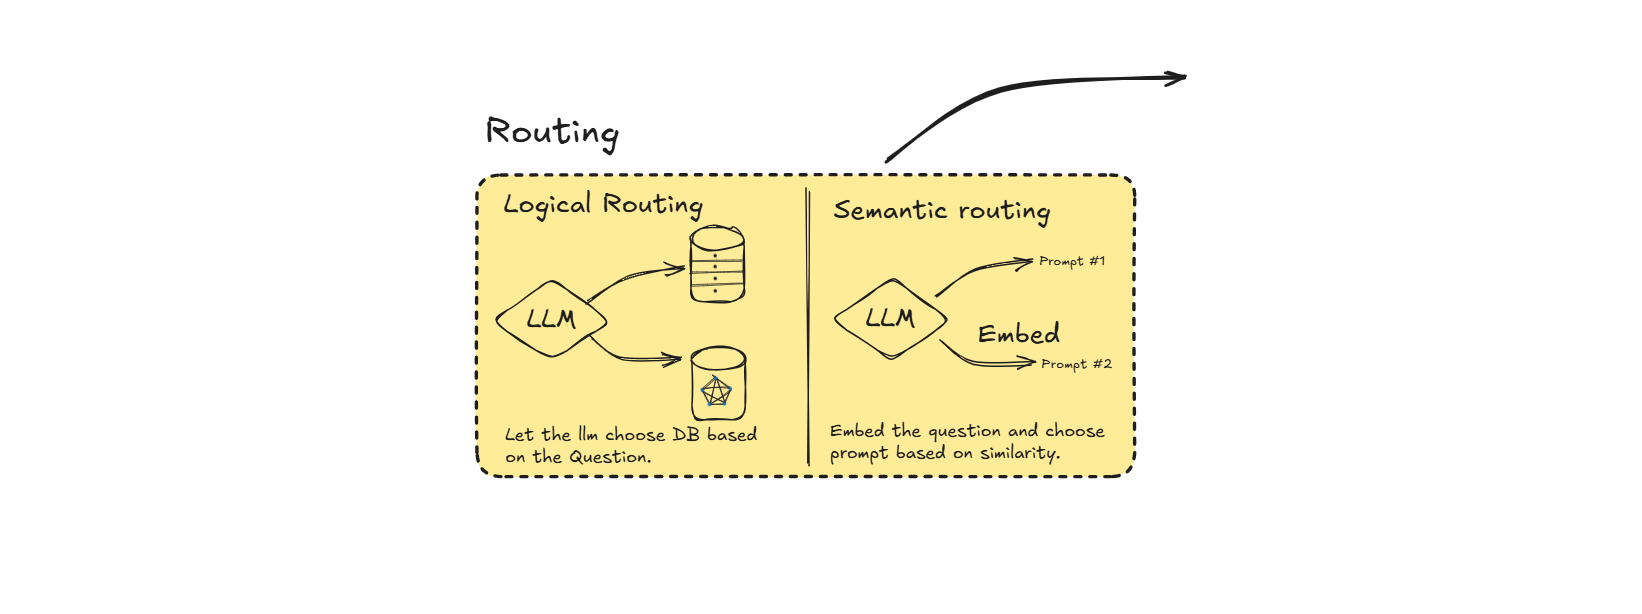

In [ ]:
from IPython.display import Image
display(Image("/content/Screenshot 2025-09-06 004759.png"))

##Enviornment
(1) Packages

In [1]:
%%capture
! pip install langchain_community tiktoken langchain-openai langchainhub chromadb langchain langchain_groq

##Tracing:
Optionally, use LangSmith for tracing (shown at bottom) by setting:

In [2]:
from google.colab import userdata
import os

os.environ['LANGSMITH_API_KEY'] = userdata.get('LANGSMITH_API_KEY')
os.environ['LANGCHAIN_TRACING_V2'] = 'true'
os.environ["LANGCHAIN_PROJECT"] ="Routing to datasources"

##Part 1: Logical and semantic routing
Use function-calling for classification.<br>
Flow:

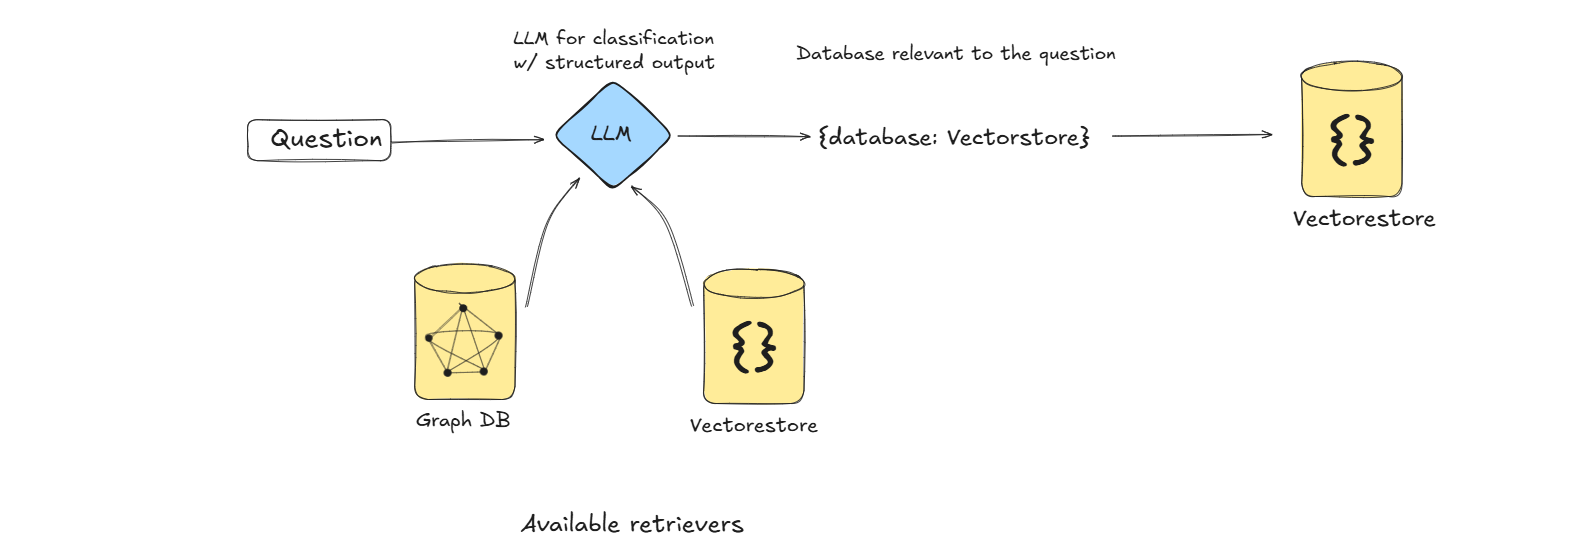

In [ ]:
display(Image("/content/Screenshot 2025-09-06 011647.png"))

Docs:
https://python.langchain.com/docs/use_cases/query_analysis/techniques/routing#routing-to-multiple-indexes

In [3]:
# Imports
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.pydantic_v1 import BaseModel, Field
from langchain_groq import ChatGroq
from google.colab import userdata

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3553: LangChainDeprecationWarning: As of langchain-core 0.3.0, LangChain uses pydantic v2 internally. The langchain_core.pydantic_v1 module was a compatibility shim for pydantic v1, and should no longer be used. Please update the code to import from Pydantic directly.

For example, replace imports like: `from langchain_core.pydantic_v1 import BaseModel`
with: `from pydantic import BaseModel`
or the v1 compatibility namespace if you are working in a code base that has not been fully upgraded to pydantic 2 yet. 	from pydantic.v1 import BaseModel

  exec(code_obj, self.user_global_ns, self.user_ns)


In [4]:
# Data Model
class RoutingQuery(BaseModel):
  """Route a user query to the most relevant datasource."""

  datasource: Literal['Python_docs', 'js_docs', 'golang_docs'] = Field(
      ...,
      description = "Given a user question choose which datasource would be most relevant for answering the question.",
  )

# LLM with function call
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct", # you can switch to other Groq-supported models
    temperature=0)

structured_llm = llm.with_structured_output(RoutingQuery)


In [5]:
# Prompts
system = """
you are an expert at routing a user question to the appropriate data source.
Based on the programming language the question is referring to, route it to relevant data source. """

In [6]:
prompt = ChatPromptTemplate.from_messages([
    ("system", system),
    ("human", "{question}")
])

In [7]:
# define router
router = prompt | structured_llm

Note: we have used function calling to produce structured output.

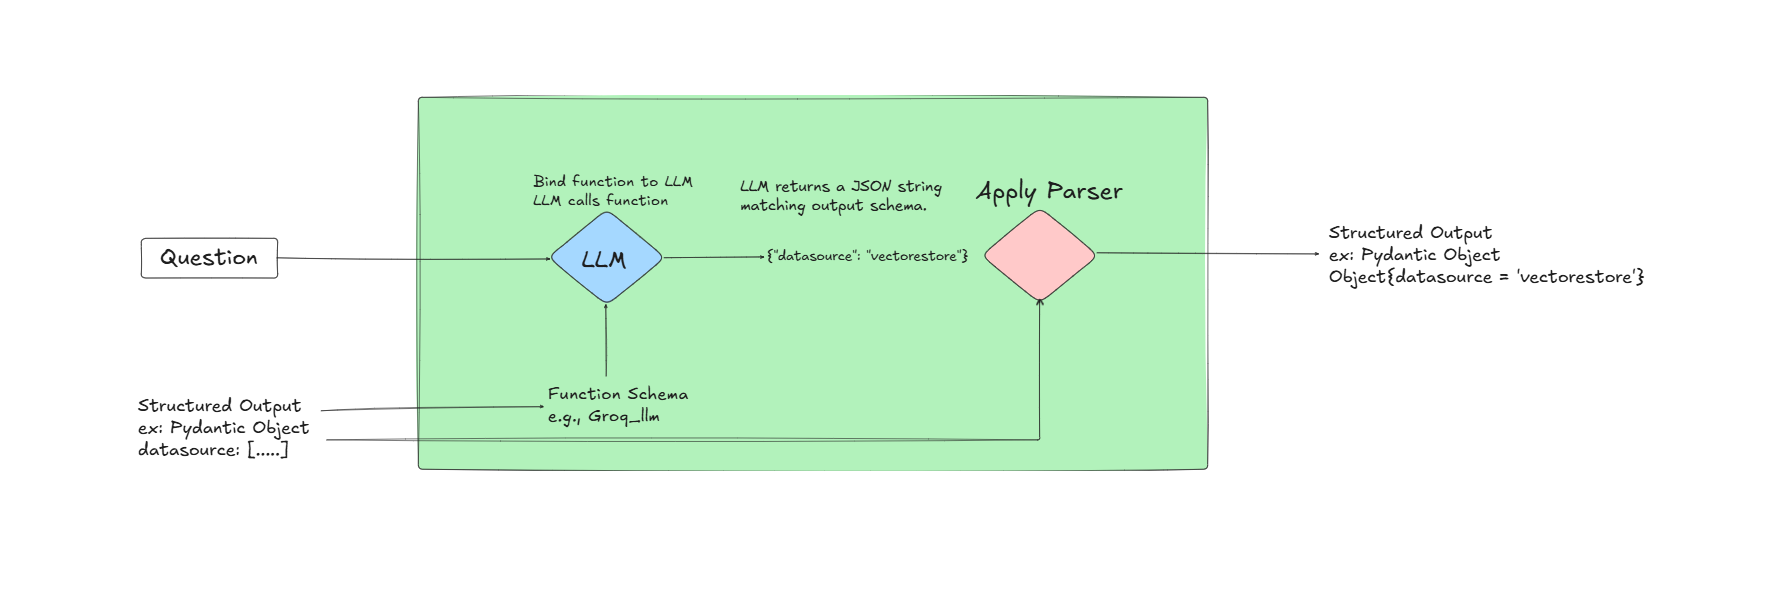

In [ ]:
display(Image("/content/Screenshot 2025-09-06 021255.png"))

In [8]:
question = """Why doesn't the following code work:

from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages(["human", "speak in {language}"])
prompt.invoke("french")
"""

result = router.invoke({"question": question})

In [9]:
result

RoutingQuery(datasource='Python_docs')

In [10]:
result.datasource

'Python_docs'

In [11]:
def choose_route(result):
    if "python_docs" in result.datasource.lower():
        ### Logic here
        return "chain for python_docs"
    elif "js_docs" in result.datasource.lower():
        ### Logic here
        return "chain for js_docs"
    else:
        ### Logic here
        return "golang_docs"

from langchain_core.runnables import RunnableLambda

full_chain = router | RunnableLambda(choose_route)

In [12]:
full_chain.invoke({"question": question})

'chain for python_docs'

##Part 1.1: Semantic Routing:

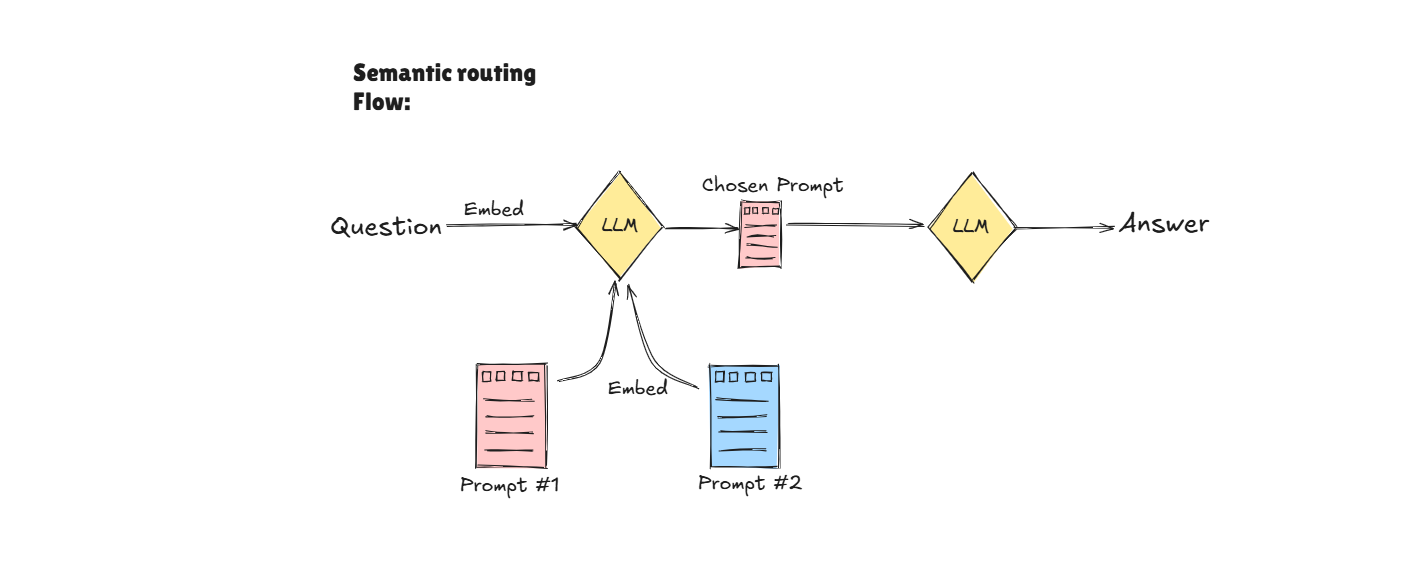

In [ ]:
display(Image("/content/Screenshot 2025-09-06 023320.png"))

In [13]:
# Imports
from langchain.utils.math import cosine_similarity
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_community.embeddings import SentenceTransformerEmbeddings

In [14]:
# Two prompts
physics_template = """You are a very smart physics professor. \
You are great at answering questions about physics in a concise and easy to understand manner. \
When you don't know the answer to a question you admit that you don't know.

Here is a question:
{query}"""

math_template = """You are a very good mathematician. You are great at answering math questions. \
You are so good because you are able to break down hard problems into their component parts, \
answer the component parts, and then put them together to answer the broader question.

Here is a question:
{query}"""

In [15]:
# Embed prompts
embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
prompt_templates = [physics_template, math_template]
prompt_embeddings = embeddings.embed_documents(prompt_templates)

/tmp/ipython-input-4149485788.py:2: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = SentenceTransformerEmbeddings(model_name="all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  wa

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
# LLM with function call
# LLM (Groq)
llm = ChatGroq(
    groq_api_key=userdata.get('GROQ_API_KEY'),  # Use userdata.get to retrieve the key
    model="moonshotai/kimi-k2-instruct", # you can switch to other Groq-supported models
    temperature=0)

In [17]:
# Route question to prompt
def prompt_router(input):
    # Embed question
    query_embedding = embeddings.embed_query(input["query"])
    # Compute similarity
    similarity = cosine_similarity([query_embedding], prompt_embeddings)[0]
    most_similar = prompt_templates[similarity.argmax()]
    # Chosen prompt
    print("Using MATH" if most_similar == math_template else "Using PHYSICS")
    return PromptTemplate.from_template(most_similar)

In [18]:
chain = (
    {"query": RunnablePassthrough()}
    | RunnableLambda(prompt_router)
    | llm
    | StrOutputParser()
)
print(chain.invoke("What's a black hole"))

Using PHYSICS
A black hole is a region of space where gravity is so strong that nothing—not even light—can escape from it. It forms when a massive star collapses under its own gravity, compressing its mass into an incredibly small and dense point called a singularity. Surrounding the singularity is the event horizon, the "point of no return" beyond which nothing can escape.


Traces:<br>
https://smith.langchain.com/public/38369482-40d8-4799-ad0b-90ddd4eb24a1/r <br>
https://smith.langchain.com/public/55804cfc-8623-483b-883f-a344d65d97ee/r
